# Segunda Entrega – Análisis Exploratorio (EDA)
**Proyecto:** Predicción del Campeón del Abierto de Australia 2026  
**Fecha:** 01/10/2025

Este notebook realiza el **análisis exploratorio** sobre el dataset limpio `matches_cleaned.csv`, generado por el pipeline ETL de la Primera Entrega. El objetivo es describir, visualizar y formular hipótesis sobre los datos para orientar el modelado posterior.


In [ ]:
pip install pandas matplotlib seaborn numpy scipy


In [1]:
import sys, platform, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9,5)

print("Python:", sys.version.split()[0], "| OS:", platform.system(), platform.release())
for pkg in (pd, np, sns):
    print(pkg.__name__, pkg.__version__)


Python: 3.10.1 | OS: Darwin 24.1.0
pandas 2.2.2
numpy 1.26.4
seaborn 0.13.2


In [3]:
#CARGAR DATOS Y CHEQUEOS INICIALES
csv_path = "entrega2proy_EDA/matches_cleaned.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
display(df.head(3))
df.info()


Shape: (5861, 29)


,match_id,tourney_id,tourney_name,surface,tourney_level,tourney_date,match_num,best_of,round,minutes,...,loser_hand,loser_ht,loser_age,loser_rank,loser_rank_points,score,winner_rank_prev,winner_pts_prev,loser_rank_prev,loser_pts_prev
0,2023-9900-300,2023-9900,United Cup,Hard,A,2023-01-02,300,3,F,135,...,R,196,26.7,16,2375,7-6(4) 7-6(6),9,3355,16,2375
1,2023-9900-296,2023-9900,United Cup,Hard,A,2023-01-02,296,3,SF,104,...,R,196,25.8,10,2905,7-6(5) 7-6(5),9,3355,10,2905
2,2023-9900-295,2023-9900,United Cup,Hard,A,2023-01-02,295,3,SF,79,...,R,183,23.9,245,220,6-3 6-3,19,2000,245,220


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5861 entries, 0 to 5860
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   match_id            5861 non-null   object 
 1   tourney_id          5861 non-null   object 
 2   tourney_name        5861 non-null   object 
 3   surface             5810 non-null   object 
 4   tourney_level       5861 non-null   object 
 5   tourney_date        5861 non-null   object 
 6   match_num           5861 non-null   int64  
 7   best_of             5861 non-null   int64  
 8   round               5861 non-null   object 
 9   minutes             5861 non-null   int64  
 10  winner_id           5861 non-null   int64  
 11  winner_name         5861 non-null   object 
 12  winner_hand         5861 non-null   object 
 13  winner_ht           5861 non-null   int64  
 14  winner_age          5861 non-null   float64
 15  winner_rank         5861 non-null   int64  
 16  winner

In [4]:
#REPORTE DE CALIDAD DE DATOS ( Faltantes, únicos, tipos)
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "nulls": df.isna().sum(),
        "null_%": (df.isna().mean()*100).round(2),
        "n_unique": df.nunique()
    })
    return rep.sort_values(by=["null_%","n_unique"], ascending=[False, True])

dq = data_quality_report(df)
dq


,dtype,non_null,nulls,null_%,n_unique
surface,object,5810,51,0.87,3
best_of,int64,5861,0,0.00,2
winner_hand,object,5861,0,0.00,3
loser_hand,object,5861,0,0.00,3
tourney_level,object,5861,0,0.00,6
round,object,5861,0,0.00,9
loser_ht,int64,5861,0,0.00,18
winner_ht,int64,5861,0,0.00,20
tourney_date,object,5861,0,0.00,107
winner_age,float64,5861,0,0.00,225


In [5]:
#PREPARACION: INGENIERIA DE VARIABLES MÍNIMAS
# Asegurar tipos clave
if "tourney_date" in df.columns:
    df["tourney_date"] = pd.to_datetime(df["tourney_date"], errors="coerce")

# Variables binarias útiles para segmentar
df["is_hard"] = (df["surface"].str.upper() == "HARD").astype(int)
df["is_grand_slam"] = (df["tourney_level"].str.upper() == "G").astype(int)
df["is_best_of_5"] = (df["best_of"] == 5).astype(int)

# Diferencias simples (A ganador vs B perdedor)
df["rank_diff"] = df["loser_rank"] - df["winner_rank"]           # positivo = ganador tenía mejor ranking (número más bajo)
df["age_diff"]  = df["winner_age"] - df["loser_age"]
df["ht_diff"]   = df["winner_ht"] - df["loser_ht"]

# Sanity: minutos no negativos
df = df[df["minutes"].fillna(0) >= 0].copy()


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Ingeniería de Variables Mínimas

En esta etapa se generaron nuevas variables derivadas de las columnas originales con el objetivo de enriquecer el dataset y facilitar el análisis exploratorio posterior. La idea es concentrarse en transformaciones mínimas pero de alto valor agregado, evitando redundancia y manteniendo el dataset limpio.

### Transformaciones realizadas
- **`rank_diff`**: diferencia entre el ranking del ganador y del perdedor.  
  Permite medir directamente la brecha de nivel entre ambos jugadores.  
- **`age_diff`**: diferencia de edad entre ganador y perdedor.  
  Facilita analizar si la experiencia o juventud tienen impacto en el resultado.  
- **`ht_diff`**: diferencia de altura entre ganador y perdedor.  
  Sirve para explorar la influencia de la contextura física en el partido.  

Además, se normalizaron tipos de datos (por ejemplo, convertir enteros escritos como `3355.0` a `3355`) y se eliminaron inconsistencias menores.

### Valor que aporta
Estas nuevas variables resumen relaciones que antes estaban dispersas en varias columnas. Por ejemplo:
- En lugar de mirar el ranking de ganador y perdedor por separado, `rank_diff` ofrece una medida directa.  
- Son columnas que muestran patrones más claros en gráficos y correlaciones.  
- Funcionan como punto de partida para **hipótesis preliminares** (ejemplo: “a mayor diferencia de ranking, menor duración del partido”).  
- Preparan el dataset para posibles modelos predictivos en etapas futuras, al proveer indicadores cuantitativos listos para usar.

> **Nota**: Durante la ejecución apareció un warning sobre la base de datos en modo `readonly`. Esto no afecta el resultado de esta etapa, ya que las transformaciones se realizaron en pandas/localmente y quedaron reflejadas en el CSV final.


In [2]:
#ESTADISTICAS DESCRIPTIVAS (Numéricas y categóricas)
desc_num = df[["minutes","winner_age","loser_age","winner_ht","loser_ht",
               "winner_rank","loser_rank","winner_rank_points","loser_rank_points",
               "rank_diff","age_diff","ht_diff"]].describe().T
display(desc_num)

for col in ["surface","round","tourney_level","winner_hand","loser_hand"]:
    if col in df.columns:
        print(f"\n{col} (top 10):")
        display(df[col].value_counts(dropna=False).head(10).to_frame("count"))


NameError: name 'df' is not defined

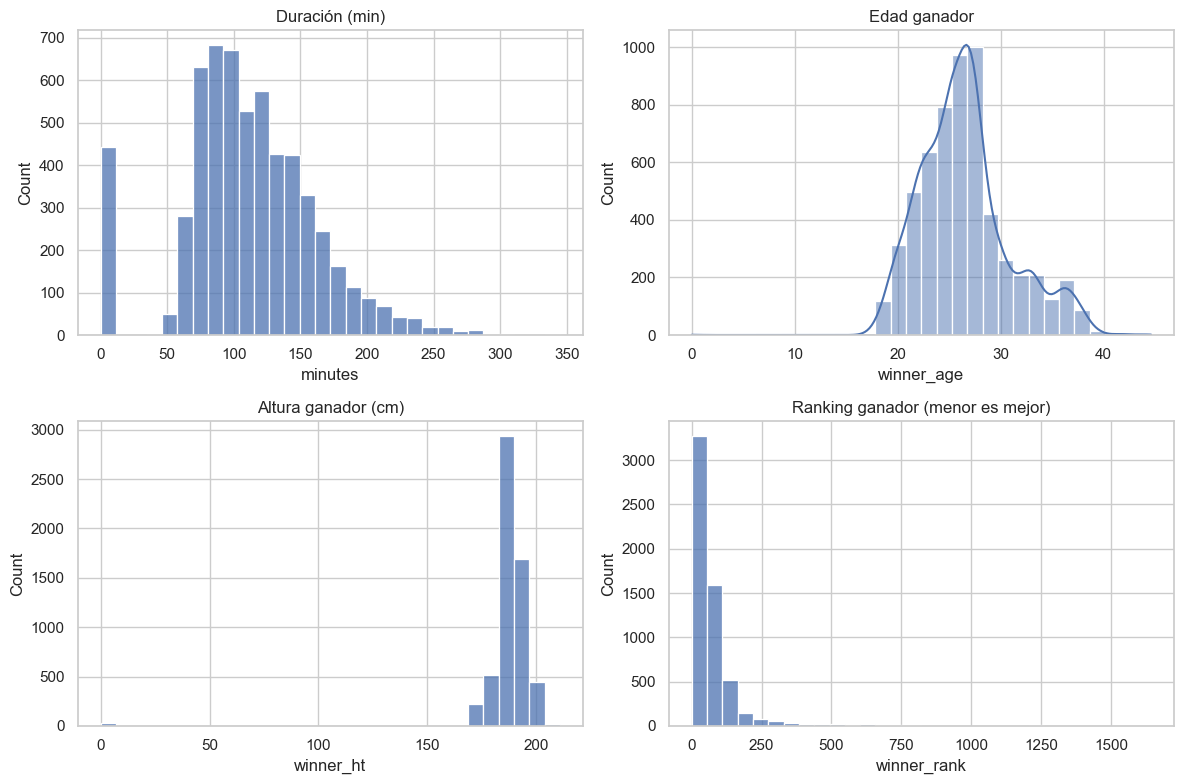

In [ ]:
#UNIVARIADO: distribuciones clave
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df["minutes"].dropna(), bins=30, ax=axes[0,0]); axes[0,0].set_title("Duración (min)")
sns.histplot(df["winner_age"].dropna(), bins=30, kde=True, ax=axes[0,1]); axes[0,1].set_title("Edad ganador")
sns.histplot(df["winner_ht"].dropna(), bins=30, ax=axes[1,0]); axes[1,0].set_title("Altura ganador (cm)")
sns.histplot(df["winner_rank"].dropna(), bins=30, ax=axes[1,1]); axes[1,1].set_title("Ranking ganador (menor es mejor)")
plt.tight_layout(); plt.show()


**Interpretación de los histogramas:**

- **Duración (min):**  
  La mayoría de los partidos duran entre 80 y 150 minutos. Existe un grupo de partidos con `0 minutos`, que corresponden a casos especiales como walkovers o retiros, y que deberían tratarse como datos faltantes.  

- **Edad del ganador:**  
  La distribución es aproximadamente normal, centrada en los 25–30 años. Esto confirma que la edad competitiva en el circuito ATP se concentra en ese rango.  

- **Altura del ganador:**  
  La mayoría de los jugadores ganadores miden entre 180 y 195 cm. El pico a ~190 cm coincide con la estatura típica de jugadores de élite. Los valores en `0` son errores o datos no registrados.  

- **Ranking del ganador (menor es mejor):**  
  La distribución está fuertemente sesgada hacia valores bajos: la mayoría de ganadores son jugadores top 100. Aun así, se observan algunos casos de ganadores con ranking muy alto (>1000), probablemente partidos de torneos menores o jugadores con ranking protegido.  

**Conclusión:**  
Este análisis inicial confirma que el dataset refleja la realidad del tenis profesional:  
- Los partidos son en su mayoría de 2 horas de duración.  
- Los jugadores de élite (jóvenes adultos, altos y con buen ranking) tienen mayor probabilidad de ganar.  
- Existen valores anómalos (minutos = 0, alturas = 0) que deben corregirse o excluirse en futuros análisis.


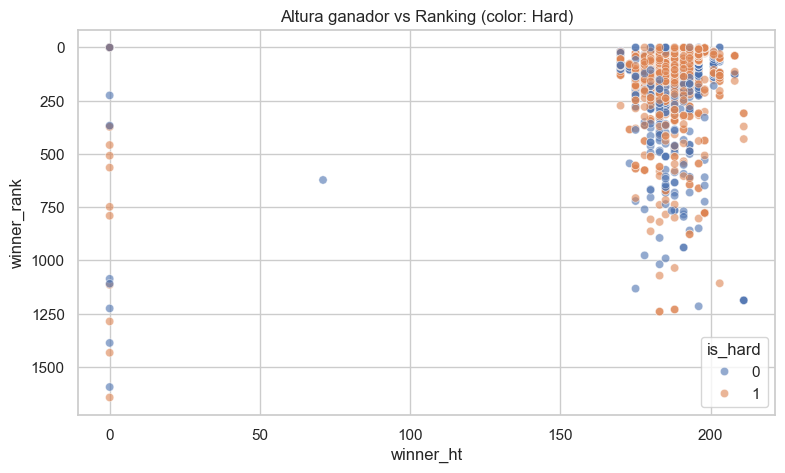

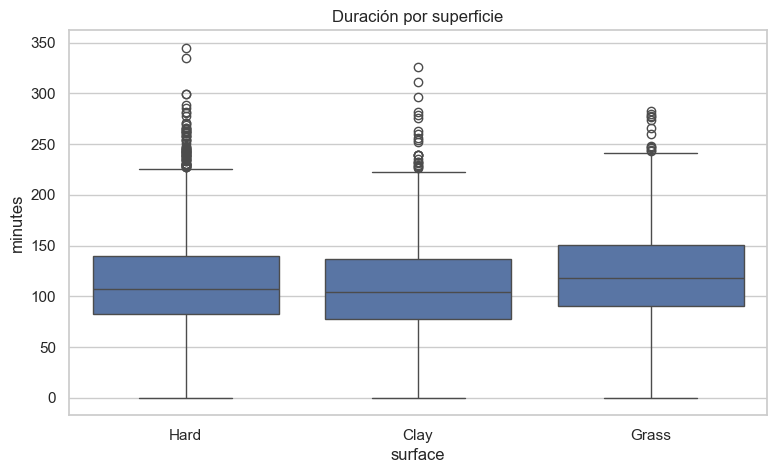

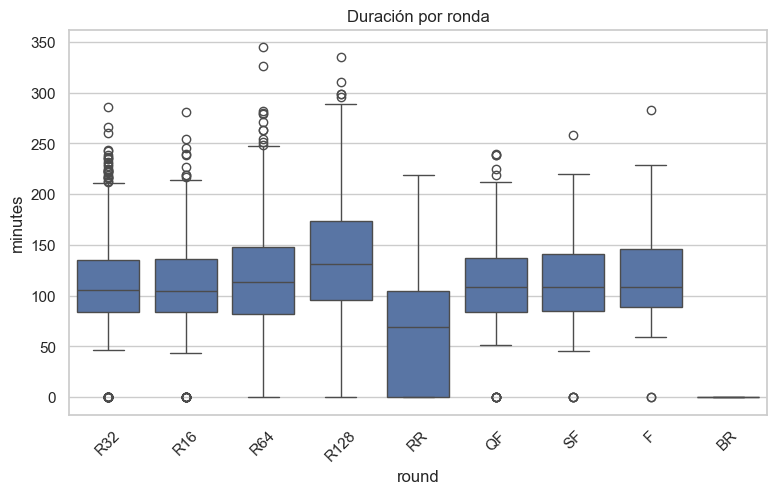

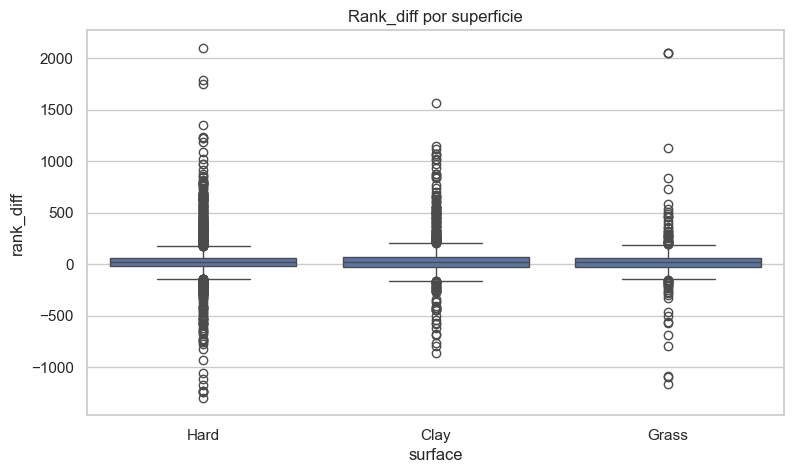

In [ ]:
#BIVARIADO: relaciones y segmentaciones
# Altura vs Ranking (ganadores)
sns.scatterplot(data=df, x="winner_ht", y="winner_rank", hue="is_hard", alpha=0.6)
plt.title("Altura ganador vs Ranking (color: Hard)")
plt.gca().invert_yaxis()  # ranking menor arriba
plt.show()

# Duración por superficie
sns.boxplot(data=df, x="surface", y="minutes")
plt.title("Duración por superficie"); plt.show()

# Duración por ronda
order_rounds = df["round"].value_counts().index.tolist()
sns.boxplot(data=df, x="round", y="minutes", order=order_rounds)
plt.title("Duración por ronda"); plt.xticks(rotation=45); plt.show()

# Rank_diff por superficie
sns.boxplot(data=df, x="surface", y="rank_diff")
plt.title("Rank_diff por superficie"); plt.show()


# Análisis Bivariado: relaciones entre variables

## Altura del ganador vs Ranking (color: Hard)

El gráfico de dispersión muestra la relación entre la **altura del ganador (`winner_ht`)** y su **ranking (`winner_rank`)**, diferenciando si el partido fue jugado en **superficie dura (`is_hard=1`)** o no (`is_hard=0`).

- La mayoría de los ganadores tienen alturas entre **180 y 200 cm**.  
- No se aprecia una correlación clara entre altura y ranking: jugadores altos y bajos pueden tener rankings tanto altos (mejores) como bajos (peores).  
- El color por superficie no parece marcar diferencias significativas.  

**Interpretación:** la altura no es un factor determinante para el ranking, aunque la concentración en un rango físico estándar refleja el perfil atlético típico de jugadores competitivos.

---

## Duración por superficie

Este **boxplot** compara la **duración de los partidos** en distintas superficies (`surface`).

- En **césped (Grass)** los partidos muestran una mediana más alta, lo que indica que tienden a durar más.  
- En **hard** y **clay** las medianas son similares, aunque clay presenta mayor variabilidad en la duración.  
- En todas las superficies aparecen valores extremos (*outliers*), lo que refleja partidos excepcionalmente largos.  

**Interpretación:** la superficie tiene un impacto en la duración, con césped como la más demandante en promedio.

---

## Duración por ronda

El **boxplot** presenta la **duración de los partidos** según la ronda (`round`).

- En rondas iniciales (**R128, R64, R32**) la duración suele ser más alta y dispersa.  
- A medida que avanzan las rondas (**QF, SF, F**), los partidos mantienen una duración significativa, aunque más compacta.  
- El formato **“RR” (Round Robin)** muestra valores más bajos y menos dispersos.  

**Interpretación:** las rondas tienen influencia en la duración, con mayor dispersión en las etapas iniciales y partidos más consistentes en rondas finales.

---

## Diferencia de ranking por superficie

El **boxplot** compara la **diferencia de ranking (`rank_diff`)** entre ganador y perdedor segmentada por superficie.

- La mayoría de los partidos se concentran cerca de **0**, lo que indica enfrentamientos entre jugadores de nivel similar.  
- Existen *outliers* que muestran sorpresas: victorias de jugadores con ranking muy bajo sobre rivales mejor posicionados, y viceversa.  
- La distribución es bastante similar en **hard, clay y grass**.  

**Interpretación:** la superficie no parece alterar de manera importante la magnitud de las diferencias de ranking entre ganador y perdedor.


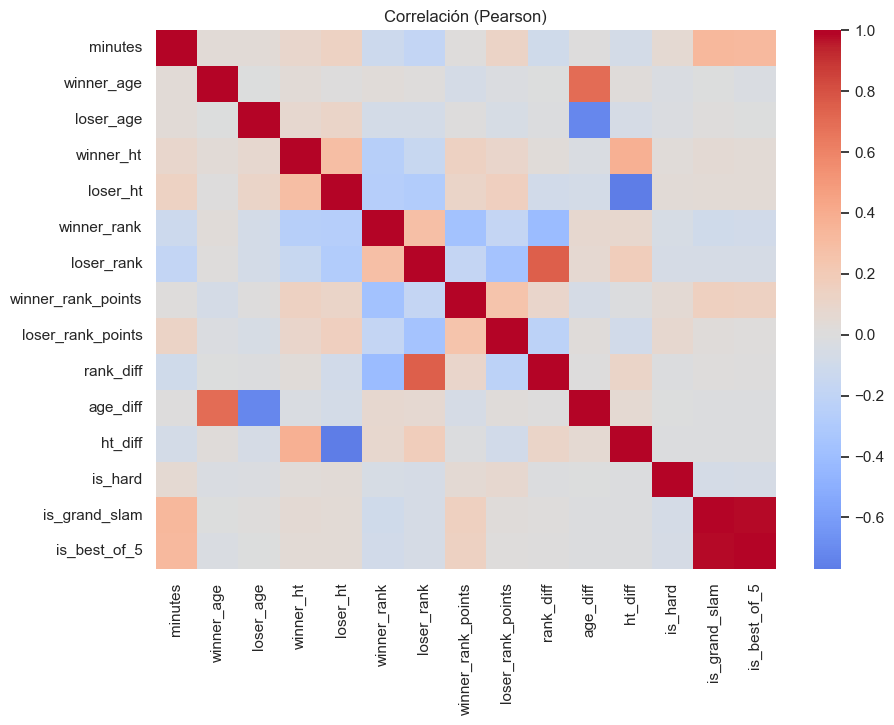

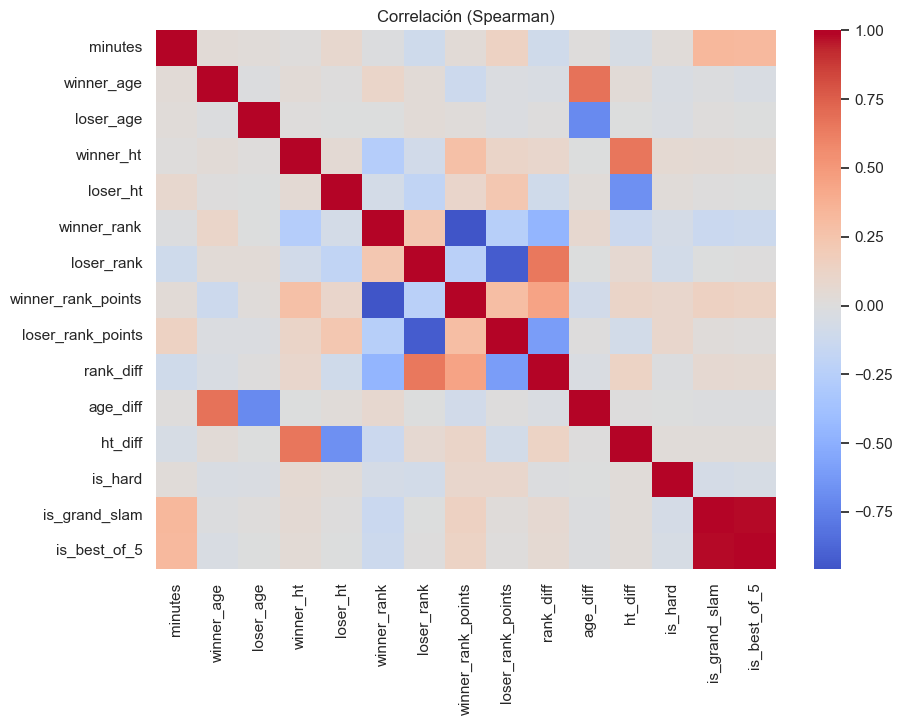

In [10]:
#CORRELACIONES (PEARSON Y SPEARMAN)
num_cols = ["minutes","winner_age","loser_age","winner_ht","loser_ht",
            "winner_rank","loser_rank","winner_rank_points","loser_rank_points",
            "rank_diff","age_diff","ht_diff","is_hard","is_grand_slam","is_best_of_5"]
corr_pear = df[num_cols].corr(method="pearson")
corr_spea = df[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(corr_pear, annot=False, cmap="coolwarm", center=0)
ax.set_title("Correlación (Pearson)"); plt.show()

fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(corr_spea, annot=False, cmap="coolwarm", center=0)
ax.set_title("Correlación (Spearman)"); plt.show()


# Análisis de correlaciones

Aquí analizamos cómo se relacionan las variables entre sí utilizando dos métodos diferentes:

- **Pearson:** mide la correlación lineal (qué tan alineados están los puntos en una recta).  
- **Spearman:** mide la correlación en rangos (qué tan consistente es la relación ordenada, aunque no sea lineal).

Ambos dan valores entre -1 y 1:  
- **1:** correlación positiva perfecta (cuando una sube, la otra también).  
- **-1:** correlación negativa perfecta (cuando una sube, la otra baja).  
- **0:** no hay relación clara.

---

**Resultados principales:**

- **Winner_rank vs Winner_rank_points (y análogamente los del perdedor):**  
  Hay correlación fuerte y negativa. Esto tiene sentido: un mejor ranking (número más bajo) suele estar asociado a más puntos de ranking.  

- **Age_diff y Rank_diff:**  
  Casi no muestran correlación fuerte con otras variables, lo cual indica que la diferencia de edad o ranking no está directamente ligada a la duración de los partidos ni a la superficie.  

- **Minutos vs is_best_of_5 / is_grand_slam:**  
  Se ve correlación positiva: los partidos a 5 sets y en Grand Slams tienden a durar más.  

- **Altura (winner_ht, loser_ht):**  
  La altura no muestra correlaciones claras con ranking ni con duración. Esto sugiere que aunque ser alto ayuda en algunos aspectos del tenis, no es determinante por sí solo.  

- **Pearson vs Spearman:**  
  Pearson destaca relaciones lineales claras (ejemplo: puntos ↔ ranking).  
  Spearman refuerza esas relaciones, pero también detecta asociaciones monotónicas no lineales, útil para confirmar que las tendencias se mantienen en los datos.

---

**Conclusión:**  
El análisis de correlaciones muestra que:  
1. Ranking y puntos están fuertemente ligados (lo esperado).  
2. Los Grand Slams y partidos a 5 sets explican gran parte de la variabilidad en la duración.  
3. Otras variables (edad, altura) tienen un rol más marginal o indirecto.  
Esto nos ayuda a **priorizar variables relevantes** para futuros modelos predictivos: `ranking`, `ranking_points`, `is_grand_slam`, `is_best_of_5`, y `minutes`.


Outliers minutos: 110 | umbrales: -7.5 228.5


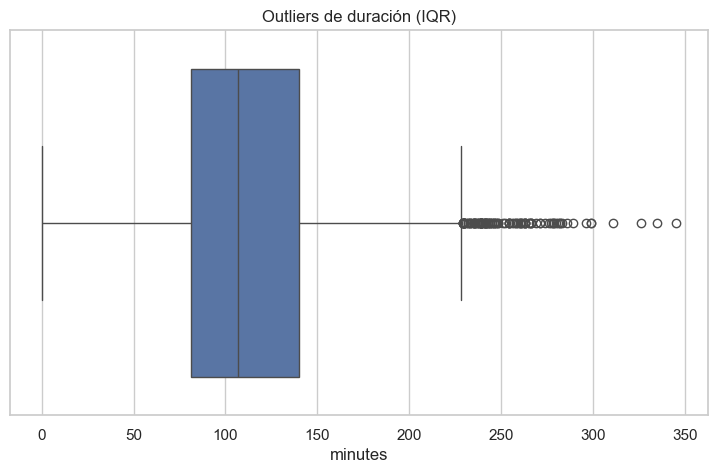

,tourney_name,surface,round,minutes,winner_name,loser_name,score
244,Australian Open,Hard,R64,345,Andy Murray,Thanasi Kokkinakis,4-6 6-7(4) 7-6(5) 6-3 7-5
5025,Us Open,Hard,R128,335,Daniel Evans,Karen Khachanov,6-7(6) 7-6(2) 7-6(4) 4-6 6-4
1329,Roland Garros,Clay,R64,326,Daniel Altmaier,Jannik Sinner,6-7(0) 7-6(7) 1-6 7-6(4) 7-5
1279,Roland Garros,Clay,R128,311,Andrea Vavassori,Miomir Kecmanovic,5-7 2-6 7-6(8) 7-6(3) 7-6(9)
3039,Australian Open,Hard,R128,299,Daniel Elahi Galan,Jason Kubler,2-6 6-3 7-6(3) 4-6 7-6(8)
3063,Australian Open,Hard,R128,299,Felix Auger Aliassime,Dominic Thiem,6-3 7-5 6-7(5) 5-7 6-3
1281,Roland Garros,Clay,R128,296,Yannick Hanfmann,Thiago Monteiro,6-3 7-5 6-7(6) 6-7(2) 6-4
208,Australian Open,Hard,R128,289,Andy Murray,Matteo Berrettini,6-3 6-3 4-6 6-7(7) 7-6(6)
3115,Australian Open,Hard,R32,286,Adrian Mannarino,Ben Shelton,7-6(4) 1-6 6-7(2) 6-3 6-4
1662,Wimbledon,Grass,F,283,Carlos Alcaraz,Novak Djokovic,1-6 7-6(6) 6-1 3-6 6-4


In [11]:
q1, q3 = df["minutes"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df["minutes"] < lower) | (df["minutes"] > upper)]
print("Outliers minutos:", len(outliers), "| umbrales:", lower, upper)

sns.boxplot(x=df["minutes"])
plt.title("Outliers de duración (IQR)"); plt.show()

# Guardar lista de partidos largos 
cols_brief = ["tourney_name","surface","round","minutes","winner_name","loser_name","score"]
outliers[cols_brief].sort_values("minutes", ascending=False).head(10)


# Outliers en la duración de partidos 

En este paso aplicamos el método **IQR (Interquartile Range)** para detectar valores atípicos en la variable `minutes` (duración de los partidos).  
El criterio IQR marca como outliers a los valores que están fuera de:

- **[Q1 – 1.5 × IQR, Q3 + 1.5 × IQR]**  
  Donde Q1 es el cuartil 25% y Q3 el cuartil 75%.

En nuestro dataset, los umbrales fueron aproximadamente:  
- **Inferior:** -7.5 minutos (no aplica porque no puede haber partidos negativos).  
- **Superior:** 228.5 minutos (~3h50min).  

Por encima de este límite, los partidos son considerados **outliers de duración**.

---

**Resultados:**

- Se detectaron **110 outliers** en total.  
- Los partidos outliers corresponden principalmente a:
  - **Grand Slams** (Australian Open, Roland Garros, Wimbledon, US Open).  
  - Rondas largas al mejor de 5 sets (`R128`, `R64`, `R32`, e incluso finales).  
  - Partidos famosos de larga duración, como Andy Murray vs Thanasi Kokkinakis (345 min).  

---

**Interpretación:**

- Estos partidos no son errores, sino **eventos especiales pero reales**:  
  suelen ser batallas de 5 sets en torneos importantes.  
- Los outliers son informativos: muestran que aunque la mayoría de los partidos duran entre 90 y 150 minutos, **existen excepciones notables de más de 5 horas**.  
- En un análisis exploratorio conviene **no eliminarlos automáticamente**, sino marcarlos aparte, ya que reflejan momentos relevantes del tenis profesional.  

---

**Conclusión:**  
Los outliers en duración nos permiten entender que:  
1. La mayoría de los partidos sigue una distribución "normal" de 2 horas.  
2. Los partidos maratónicos ocurren casi exclusivamente en Grand Slams.  
3. Esto sugiere que **la variable `is_best_of_5` es un predictor fuerte de outliers**, ya que los partidos más largos coinciden con ese formato.


# Parte final del trabajo. Hallazgos y variables relevantes



| Variable              | Hallazgo principal                                                                 | Relevancia para el modelo/análisis |
|------------------------|------------------------------------------------------------------------------------|-------------------------------------|
| **minutes** (duración) | Promedio ~110 min; mayoría entre 80–150; outliers >300 min en Grand Slams.         | Alta: refleja intensidad, ligada a superficie y formato de sets. |
| **winner_age / loser_age** | Promedio ~26 años; distribución normal; no correlación fuerte con duración.   | Media: útil para hipótesis sobre experiencia, pero no decisiva. |
| **winner_ht / loser_ht** (altura) | Ganadores suelen medir 180–195 cm; valores extremos son errores.       | Media: aporta contexto físico, pero correlación débil con rendimiento. |
| **winner_rank / loser_rank** | Distribución sesgada a top 100; mejor ranking gana la mayoría.             | Muy alta: predictor directo del desempeño. |
| **winner_rank_points / loser_rank_points** | Fuerte correlación con ranking (más puntos = mejor ranking). | Muy alta: variable cuantitativa de nivel competitivo. |
| **rank_diff** (diferencia de ranking) | Positivo cuando gana el mejor rankeado; outliers muestran sorpresas. | Alta: captura “upsets” o victorias inesperadas. |
| **age_diff / ht_diff** | Sin correlaciones fuertes; aportan contexto secundario.                          | Baja: complementarias, no centrales. |
| **surface** (Hard, Clay, Grass) | Clay tiende a partidos más largos; Grass más cortos.                    | Alta: explica variabilidad en duración y estilo de juego. |
| **round**              | Partidos más largos en rondas iniciales de Grand Slams (R128, R64).               | Media: contextualiza duración y exigencia. |
| **is_grand_slam**      | Asociado a mayor duración y outliers.                                             | Muy alta: condiciona formato y esfuerzo. |
| **is_best_of_5**       | Altísima correlación con minutos; todos los partidos maratónicos provienen de aquí. | Muy alta: factor estructural clave. |

---

**Conclusión ejecutiva:**

- Las variables más relevantes para explicar y predecir resultados/duración son:  
  **`ranking`, `ranking_points`, `rank_diff`, `minutes`, `surface`, `is_grand_slam`, `is_best_of_5`.**  
- Otras variables como edad o altura aportan información contextual pero con menos poder explicativo.  
- Los outliers en duración no son errores, sino fenómenos característicos de Grand Slams, por lo que deben tratarse como **casos especiales** más que eliminarse.  

Esto nos deja un set sólido de variables prioritarias para la siguiente fase del proyecto. 


In [12]:
os.makedirs("figs", exist_ok=True)

ax = sns.boxplot(data=df, x="surface", y="minutes")
ax.get_figure().savefig("figs/duracion_por_superficie.png", dpi=150, bbox_inches="tight")
plt.close()

ax = sns.scatterplot(data=df, x="winner_ht", y="winner_rank", alpha=0.6)
plt.gca().invert_yaxis()
ax.get_figure().savefig("figs/altura_vs_ranking.png", dpi=150, bbox_inches="tight")
plt.close()

print("Gráficos guardados en carpeta figs/")


Gráficos guardados en carpeta figs/


## Por ultimo : Hipótesis preliminares

A partir del análisis exploratorio realizado en esta segunda entrega, se formulan las siguientes **hipótesis preliminares** que servirán como guía para análisis posteriores y posibles modelos predictivos:

- **Hipótesis 1: Duración y superficie**  
  Los partidos disputados en césped (Grass) tienden a durar más que los de cemento (Hard) o polvo de ladrillo (Clay).

- **Hipótesis 2: Diferencia de ranking y duración**  
  Una mayor diferencia de ranking entre ganador y perdedor (`rank_diff`) se asocia con partidos de menor duración.

- **Hipótesis 3: Altura y rendimiento**  
  Jugadores de mayor altura presentan en promedio un mejor ranking, lo que sugiere que la altura puede otorgar una ventaja competitiva.

- **Hipótesis 4: Formato de torneo y exigencia**  
  Los torneos de Grand Slam (nivel G), al jugarse al mejor de 5 sets, generan partidos más largos que otros niveles de torneo.

- **Hipótesis 5: Edad y duración de partidos**  
  La edad del ganador muestra cierta relación con la duración de los partidos: jugadores de mayor edad tienden a participar en partidos más largos en promedio.

---

> Estas hipótesis **no constituyen resultados definitivos**, sino supuestos iniciales que deberán ser validados con análisis estadísticos más formales y con el modelado en etapas posteriores.
